In [1]:
import pandas as pd

df = pd.read_csv('spam.csv', encoding='latin-1')
print(df.shape)
df.head()

(5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [2]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df['label'].value_counts()
df['label'].value_counts(normalize=True) * 100

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

In [5]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                          # lowercase everything
    text = re.sub(r'[^a-z\s]', '', text)          # remove punctuation/numbers
    words = text.split()                          # split into individual words
    words = [w for w in words if w not in stop_words]  # remove stopwords
    return ' '.join(words)

df['clean_message'] = df['message'].apply(clean_text)
df[['message', 'clean_message']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['clean_message'])
y = df['label']

print(X.shape)

(5572, 8389)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(4457, 8389) (1115, 8389)


In [8]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)

y_pred_nb = model_nb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.9641255605381166
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.73      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.96      0.96      1115



### Why Recall Matters for Spam Detection
In spam detection, **recall** (catching actual spam messages) is often more important 
than precision (avoiding false alarms). A missed spam email (low recall) means a 
phishing/scam message reaches the user's inbox — a real risk. A false positive 
(low precision) just means one legitimate email gets flagged as spam, an 
annoyance but far less costly, especially if the user can check a spam folder. 
This means spam filters often deliberately tolerate more false positives in 
exchange for catching more true spam.

In [9]:
from sklearn.linear_model import LogisticRegression

model_lr2 = LogisticRegression(max_iter=1000)
model_lr2.fit(X_train, y_train)

y_pred_lr2 = model_lr2.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr2))
print(classification_report(y_test, y_pred_lr2))

Accuracy: 0.95695067264574
              precision    recall  f1-score   support

         ham       0.95      1.00      0.98       966
        spam       0.99      0.68      0.81       149

    accuracy                           0.96      1115
   macro avg       0.97      0.84      0.89      1115
weighted avg       0.96      0.96      0.95      1115



### Model Comparison

| Model | Accuracy | Spam Precision | Spam Recall | Spam F1 |
|---|---|---|---|---|
| Multinomial Naive Bayes | 0.964 | 1.00 | 0.73 | 0.84 |
| Logistic Regression | 0.957 | 0.99 | 0.68 | 0.81 |

**Multinomial Naive Bayes** is selected as the better model for this task. While 
both models achieve near-identical, extremely high precision on spam (near 100%, 
meaning almost zero false alarms), Naive Bayes catches more actual spam messages 
(73% recall vs. 68%). Since missing real spam is the costlier error type in this 
context, the model with higher recall is preferred, even though its overall 
accuracy is only marginally different.

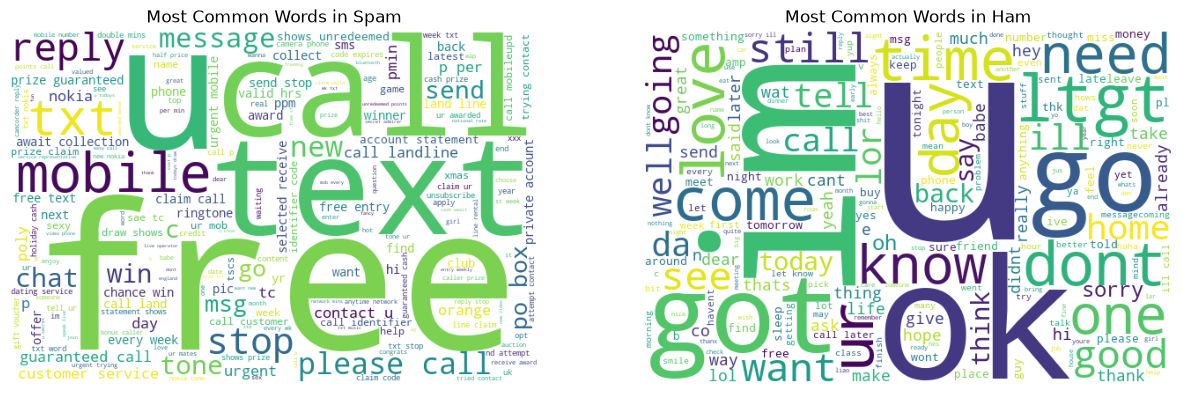

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

spam_words = ' '.join(df[df['label']=='spam']['clean_message'])
ham_words = ' '.join(df[df['label']=='ham']['clean_message'])

plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.imshow(WordCloud(width=600, height=400, background_color='white').generate(spam_words))
plt.axis('off')
plt.title('Most Common Words in Spam')

plt.subplot(1,2,2)
plt.imshow(WordCloud(width=600, height=400, background_color='white').generate(ham_words))
plt.axis('off')
plt.title('Most Common Words in Ham')

plt.show()